In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys, os
sys.path.append(os.path.expanduser('~/Desktop/Pangal'))

from pangal.pangal import PanGal
from pangal.pfitter import PFitter

from build_boissier import truncated_boissier_sfh, truncated_boissier_sed, build_boissier_SEDs, load_spectrum_models_from_fits



import warnings
warnings.filterwarnings("ignore")

In [2]:
fitter = PFitter(model_file='new_models/V_160_R_7.fit',
                 model_pars=['Q_AGE','TAU_Q','BURST','METAL'],
                )

Initializing PFitter object
Loading models from  new_models/V_160_R_7.fit
 Pre-computed model grid:
   - Q_AGE: 46 values, min=2, max=3000
   - TAU_Q: 38 values, min=1, max=2000
   - BURST: 1 values, min=0, max=0
   - METAL: 1 values, min=0.017, max=0.017


Dust attenuation curve from Calzetti 2000.
Loading nebular lines templates from  nebular_Byler_mist_2018.lines
 Emission line metallicity requested 0.0017, found 0.0020
Tabulated values for ionized gas age (Myr): [ 0.5  1.   2.   3.   4.   5.   6.   7.  10. ]
Tabulated values for ionization coefficient: [-4.  -3.5 -3.  -2.5 -2.  -1.5 -1. ]
Loading of nebular lines templates completed.
Tabulated alpha values from 'alpha_dh02.dat': [0.0625 0.125  0.1875 0.25   0.3125 0.375  0.4375 0.5    0.5625 0.625
 0.6875 0.75   0.8125 0.875  0.9375 1.     1.0625 1.125  1.1875 1.25
 1.3125 1.375  1.4375 1.5    1.5625 1.625  1.6875 1.75   1.8125 1.875
 1.9375 2.     2.0625 2.125  2.1875 2.25   2.3125 2.375  2.4375 2.5
 2.5625 2.625  2.6875 2.75   2.

# Try different quenching ages

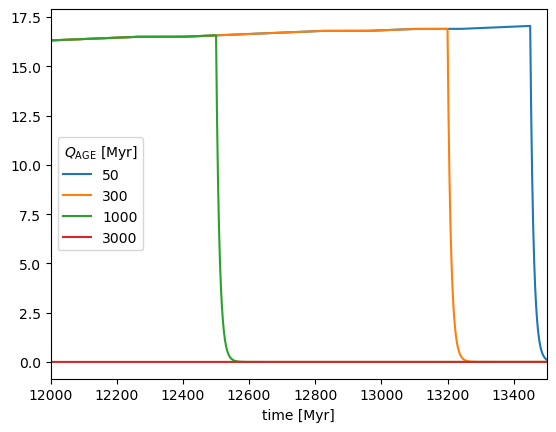

In [134]:
# MODEL PARAMETERS
vel_sys = 173
sigma_vel = 80

fesc = 0.1
ion_gas = -2.0
age_gas = 11

av = 0.0939
av_ext = 0.1
alpha = 1.775

m_star = 9.30
redshift = 0.023974
luminosity_distance = 100

TAU_Q = 10
BURST = 0

METAL = 0.017

specs_l = []
specs_h = []

for q_age in [50,300,1000,3000]:

    t,sfr = truncated_boissier_sfh(V=160,R=7,Q_age=q_age,tau_Q=TAU_Q,burst_factor=BURST,data=boissier_models)
    plt.plot(t,sfr,label=f'{q_age}')
    plt.xlim(12000,13500)
    plt.xlabel('time [Myr]')
    
    sytnh_spec_heavy = fitter_heavy.synthetic_spectrum(
        vel_sys=vel_sys,
        sigma_vel=sigma_vel,
        av=av,av_ext=av_ext,alpha=alpha,
        fesc=fesc,ion_gas=ion_gas,age_gas=age_gas,
        Q_AGE=q_age,
        TAU_Q=TAU_Q,
        BURST=BURST,METAL=METAL,
        m_star=m_star,
        redshift=redshift,luminosity_distance=luminosity_distance)
    specs_h.append(sytnh_spec_heavy)

    sytnh_spec_light = fitter_light.synthetic_spectrum(
        vel_sys=vel_sys,
        sigma_vel=sigma_vel,
        av=av,av_ext=av_ext,alpha=alpha,
        fesc=fesc,ion_gas=ion_gas,age_gas=age_gas,
        Q_AGE=q_age,
        TAU_Q=TAU_Q,
        BURST=BURST,METAL=METAL,
        m_star=m_star,
        redshift=redshift,luminosity_distance=luminosity_distance)
    specs_l.append(sytnh_spec_light)

plt.legend(title="$Q_\\text{AGE}$ [Myr]")
plt.show()

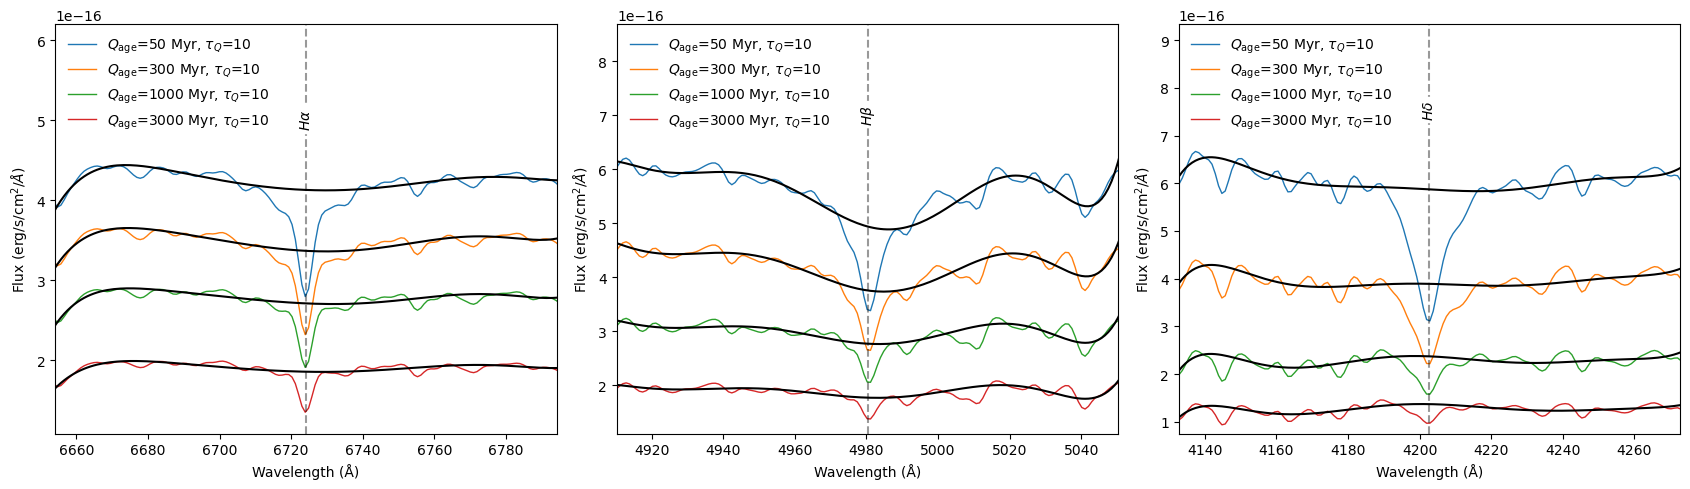

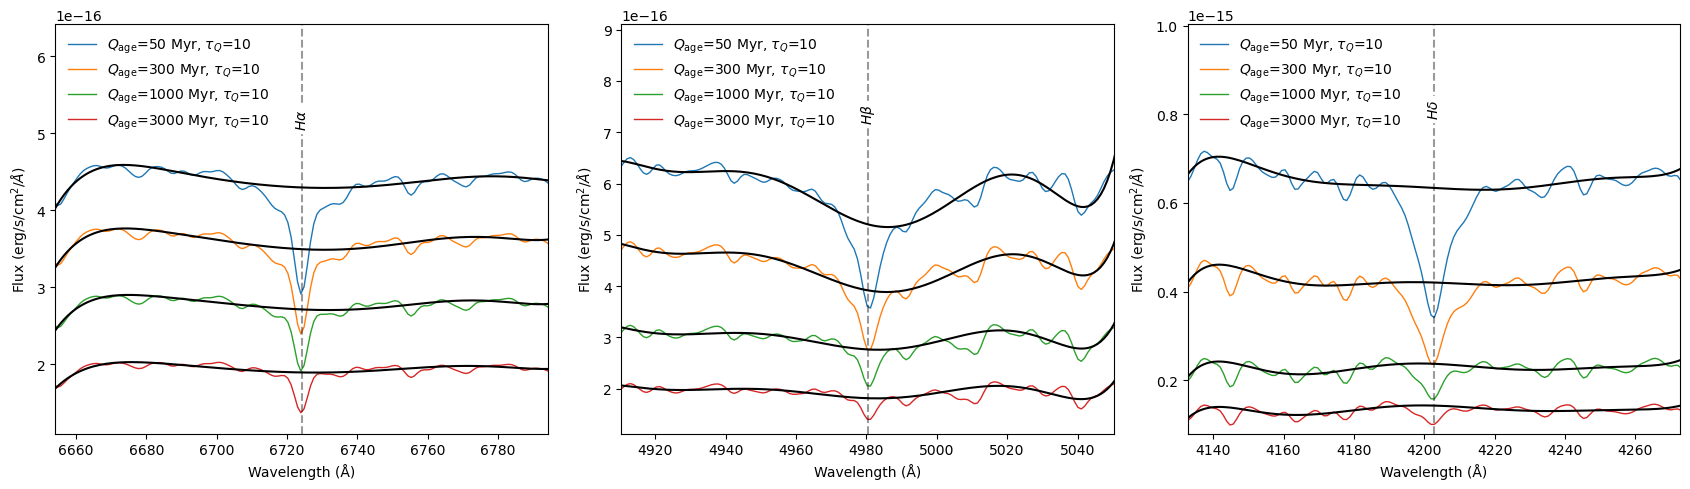

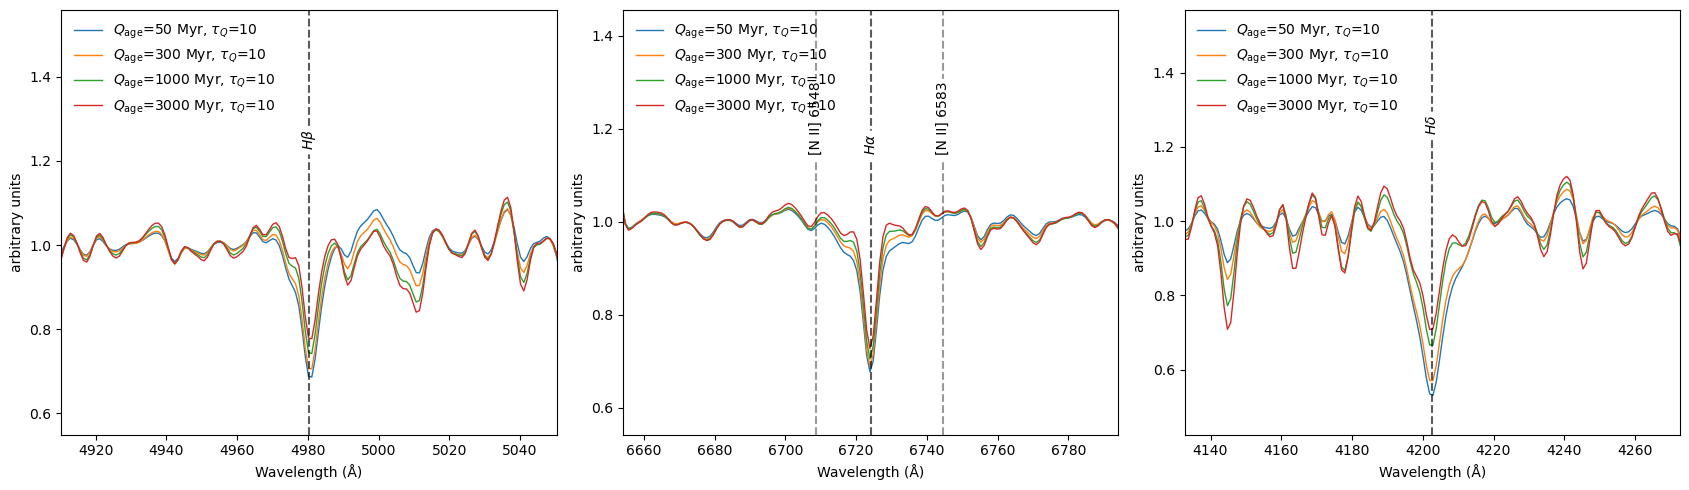

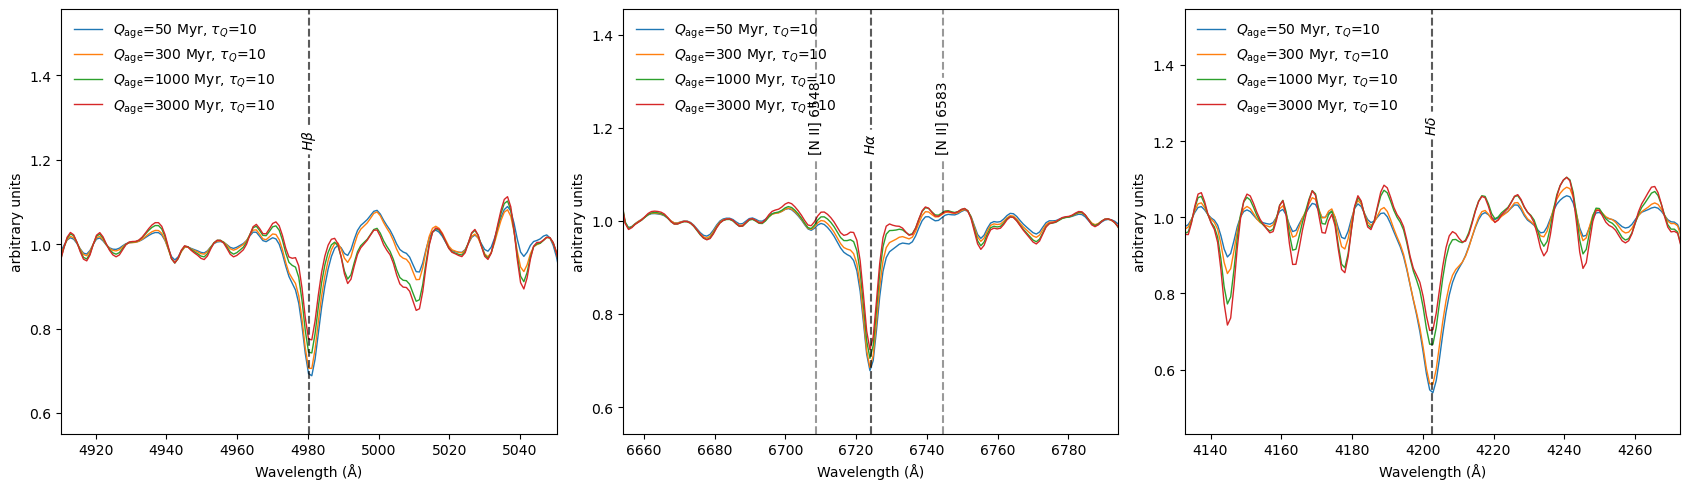

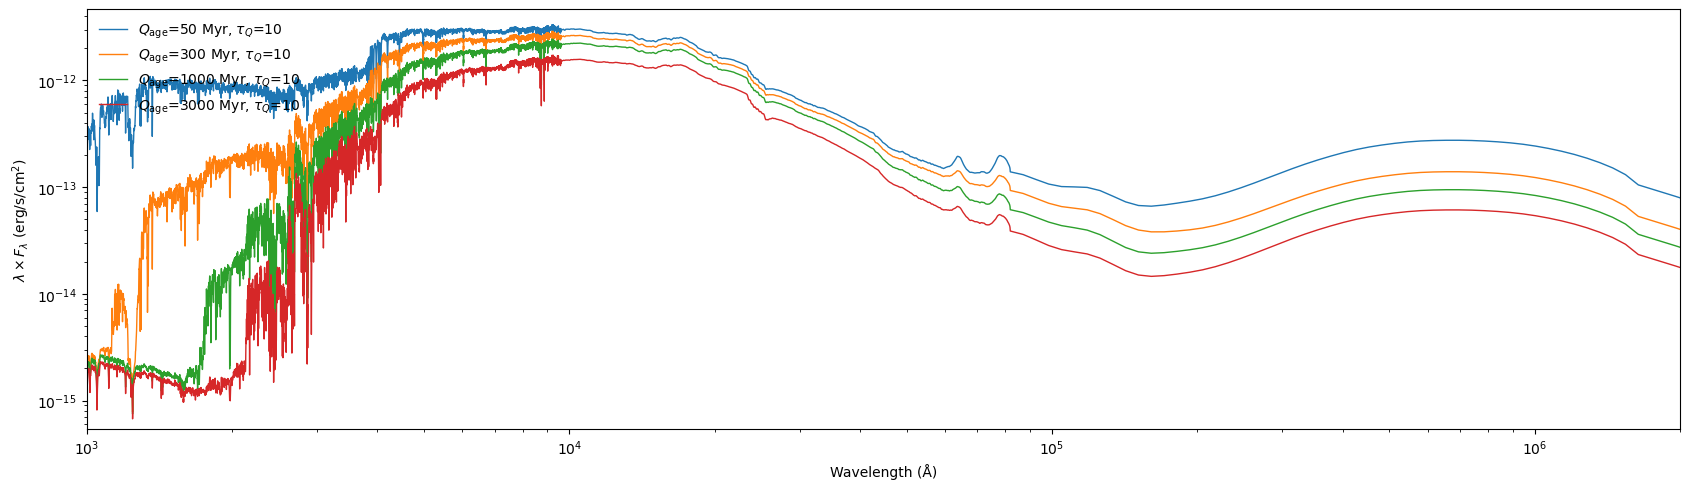

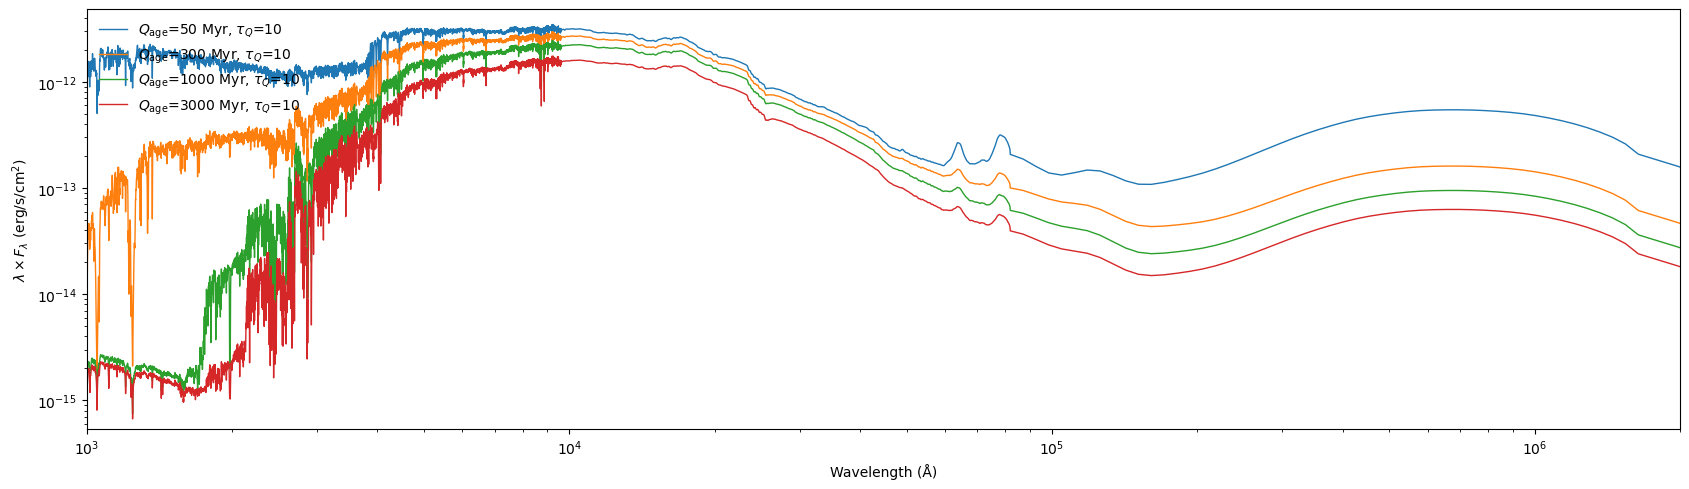

In [136]:
legend = {'Q_AGE': ["$Q_\\text{age}$", "Myr"], 'TAU_Q': ["$\\tau_Q$",""],} #'BURST': 'burst', 'METAL': 'metallicity'

specs_h[0].plot(figsize=(20,5), 
            #remove_continuum=True,
              draw_continuum=True,                      
             spectra=specs_h,
             #spectra=[spectra[0],results_with_spec.best_model(),spec_new],
            #normalized=True,
            #per_wavelength=True, 
            show_all_spectral_lines=False,show_H_lines=True,show_atmospheric_lines=True,
            zoom_on_line=['Ha','Hb','Hd'],
            winf = 4500,wsup=7000,
            #ymin = 0.5,ymax=1.5,
            spec_legend_pars=legend,
            show_phot_legend=False,
            #show_spec_legend=True,
           )

specs_h[0].plot(figsize=(20,5), 
            #remove_continuum=True,
              draw_continuum=True,                      
             spectra=specs_l,
             #spectra=[spectra[0],results_with_spec.best_model(),spec_new],
            #normalized=True,
            #per_wavelength=True, 
            show_all_spectral_lines=False,show_H_lines=True,show_atmospheric_lines=True,
            zoom_on_line=['Ha','Hb','Hd'],
            winf = 4500,wsup=7000,
            #ymin = 0.5,ymax=1.5,
            spec_legend_pars=legend,
            show_phot_legend=False,
            #show_spec_legend=True,
           )


specs[0].plot(figsize=(20,5), 
            remove_continuum=True,
              #draw_continuum=True,                      
             spectra=specs_h,
             #spectra=[spectra[0],results_with_spec.best_model(),spec_new],
            #normalized=True,
            #per_wavelength=True, 
            
            show_all_spectral_lines=True,show_H_lines=True,show_atmospheric_lines=True,
            zoom_on_line=['Hb','Ha','Hd'],
            #x_units='A',y_units='erg/s/cm2/A',
            #x_units='cm',y_units='mJy',
            #winf=1000,wsup=2e6,
            winf = 4500,wsup=7000,
            #ymin = 0.5,ymax=1.5,
            spec_legend_pars=legend,
            show_phot_legend=False,
            #show_spec_legend=True,
           )

specs[0].plot(figsize=(20,5), 
            remove_continuum=True,
              #draw_continuum=True,                      
             spectra=specs_l,
             #spectra=[spectra[0],results_with_spec.best_model(),spec_new],
            #normalized=True,
            #per_wavelength=True, 
            
            show_all_spectral_lines=True,show_H_lines=True,show_atmospheric_lines=True,
            zoom_on_line=['Hb','Ha','Hd'],
            #x_units='A',y_units='erg/s/cm2/A',
            #x_units='cm',y_units='mJy',
            #winf=1000,wsup=2e6,
            winf = 4500,wsup=7000,
            #ymin = 0.5,ymax=1.5,
            spec_legend_pars=legend,
            show_phot_legend=False,
            #show_spec_legend=True,
           )

specs[0].plot(figsize=(20,5), 
            #remove_continuum=True,
            #draw_continuum=True,                      
             spectra=specs_h,
            #normalized=True,
            per_wavelength=True, 
            winf=1000,wsup=2e6,
            #ymin = 0.5,ymax=1.5,
            spec_legend_pars=legend,
            show_phot_legend=False,
            #show_spec_legend=True,
           )

specs[0].plot(figsize=(20,5), 
            #remove_continuum=True,
            #draw_continuum=True,                      
             spectra=specs_l,
            #normalized=True,
            per_wavelength=True, 
            winf=1000,wsup=2e6,
            #ymin = 0.5,ymax=1.5,
            spec_legend_pars=legend,
            show_phot_legend=False,
            #show_spec_legend=True,
           )



# Try different velocity dispersions

In [5]:
# MODEL PARAMETERS
vel_sys = 173
#sigma_vel = 80

fesc = 0.1
ion_gas = -2.0
age_gas = 11

av = 0.0939
av_ext = 0.1
alpha = 1.775

m_star = 9.30
redshift = 0.023974
luminosity_distance = 100

Q_AGE = 100
TAU_Q = 10
BURST = 0
METAL = 0.017

specs = []

for sigma_vel in [10,50,100,500]:
    
    sytnh_spec = fitter.synthetic_spectrum(
        vel_sys=vel_sys,
        sigma_vel=sigma_vel,
        av=av,av_ext=av_ext,alpha=alpha,
        fesc=fesc,ion_gas=ion_gas,age_gas=age_gas,
        Q_AGE=Q_AGE,
        TAU_Q=TAU_Q,
        BURST=BURST,METAL=METAL,
        m_star=m_star,
        redshift=redshift,luminosity_distance=luminosity_distance)
    specs.append(sytnh_spec)


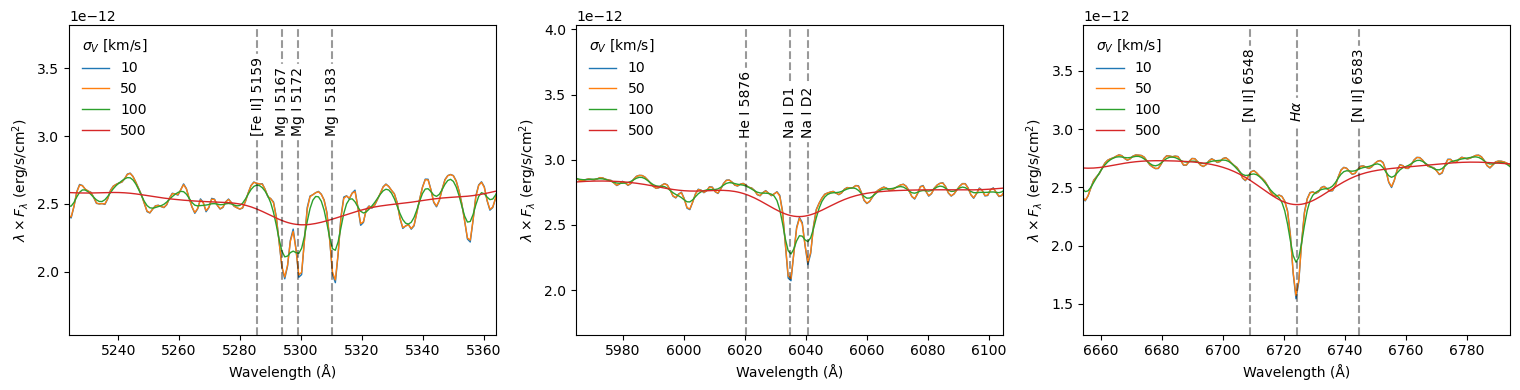

In [6]:
legend = 'SIGMA_V'
title = "$\sigma_V$ [km/s]"

specs[0].plot(spectra=specs,per_wavelength=True,show_phot_legend=False, #phot_points=phot_points, #synth_phot_points=False,phot_points=phot_points,
              winf=1000,wsup=2e6,show_all_spectral_lines=True,zoom_on_line=['Mg I 5167','Na I D1','Ha'],
              spec_legend_pars=legend,spec_legend_title=title)


# Simulate a fit

In [40]:
# MODEL PARAMETERS
vel_sys = 173
sigma_vel = 80

fesc = 0.1
ion_gas = -2.0
age_gas = 11

av = 0.0939
av_ext = 0.1
alpha = 1.775

m_star = 9.30
redshift = 0.023974
luminosity_distance = 100

q_age = 200
TAU_Q = 75
BURST = 0
METAL = 0.017

synth_spec = fitter.synthetic_spectrum(
    vel_sys=vel_sys,
    sigma_vel=sigma_vel,
    av=av,av_ext=av_ext,alpha=alpha,
    fesc=fesc,ion_gas=ion_gas,age_gas=age_gas,
    Q_AGE=q_age,
    TAU_Q=TAU_Q,
    BURST=BURST,METAL=METAL,
    m_star=m_star,
    redshift=redshift,luminosity_distance=luminosity_distance)


bands=['galex_fuv','galex_nuv','sdss_u','sdss_g','sdss_r','sdss_i','sdss_z',
       'spitzer_irac_1','spitzer_irac_2','spitzer_irac_3','spitzer_irac_4',
      'herschel_pacs_70um','herschel_pacs_100um','herschel_pacs_160um']


phot = synth_spec.get_phot(bands=bands,units='mJy')

rng = np.random.default_rng(42)

calib_frac = 0.03   # 3% zero-point uncertainty


for b in bands:

    value, _ = phot.data[b]

    # Band-dependent statistical noise (example)
    stat_frac = {
        'sdss_u': 0.10,
        'sdss_g': 0.05,
        'sdss_r': 0.03,
        'sdss_i': 0.03,
        'sdss_z': 0.05,
        'galex_nuv': 0.12,
        'galex_fuv': 0.15,
    }.get(b, 0.05)

    # Errors
    stat_err = stat_frac * value
    calib_err = calib_frac * value

    total_err = np.sqrt(stat_err**2 + calib_err**2)

    # Apply noise (same calibration bias could be shared across bands if desired)
    noisy_value = value * (1 + rng.normal(0, calib_frac)) \
                  + rng.normal(0, stat_err)

    phot.data[b] = (noisy_value, total_err)


In [35]:

# 7th-order response polynomial
# A spectrograph response:changes continuum shape. preserves relative line depths locally. is smooth in wavelength
# Define spectral range were to perform the fit

spectral_range = [4800,7000]

# Normalize wavelength to [-1, 1]
wl_min, wl_max = synth_spec.wl[0], synth_spec.wl[-1] #spectral_range
x = (synth_spec.wl - 0.5*(wl_min + wl_max)) / (0.5*(wl_max - wl_min))

rng = np.random.default_rng(42)

# Small coefficients → smooth response
coeffs = np.zeros(8)
coeffs[0] = 1.0                              # baseline normalization
coeffs[1:] = rng.normal(0, 0.03, size=7)     # higher-order terms

response = np.polyval(coeffs, x)
response = np.clip(response, 0.7, 1.3)

from pangal.spectrum import Spectrum

flux_obs = synth_spec.flux * response

flux_err = np.abs(flux_obs) * 0.05
noisy_flux = flux_obs + np.random.normal(0, flux_err)


mock_spec = Spectrum(
    wl=synth_spec.wl,
    flux=noisy_flux,
    flux_err=flux_err,
    resolution=synth_spec.resolution,
    header=synth_spec.header
)
    

In [36]:
phot.print()

,Value,Error,SNR
galex_fuv,0.025352,0.004546,5.577176
galex_nuv,0.048162,0.005247,9.179014
sdss_u,0.090507,0.011648,7.770375
sdss_g,0.361722,0.021348,16.944456
sdss_r,0.528911,0.023041,22.955153
sdss_i,0.703210,0.028422,24.742036
sdss_z,0.879076,0.048433,18.150432
spitzer_irac_1,0.532141,0.031954,16.653553
spitzer_irac_2,0.367921,0.022275,16.517344
spitzer_irac_3,0.317586,0.018087,17.559006


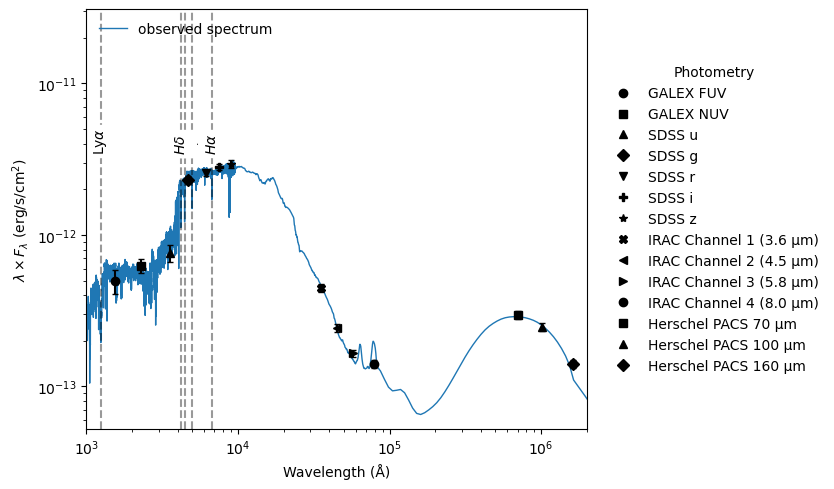

In [39]:
synth_spec.plot(figsize=(10,5),per_wavelength=True,
               show_phot_legend=True,
               phot=phot,
              winf=1000,wsup=2e6,
               #winf=4000,wsup=5000,
               show_H_lines=True,)
#synth_phot_points=bands

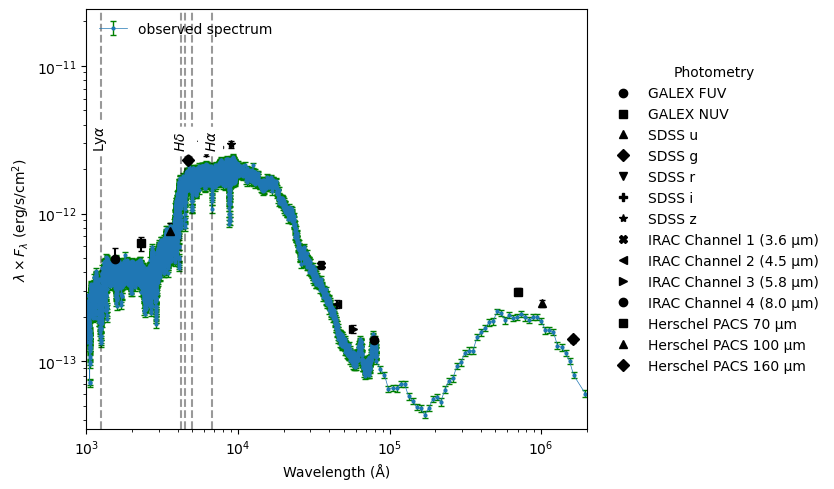

In [37]:
mock_spec.plot(figsize=(10,5),per_wavelength=True,
               show_phot_legend=True,
               phot=phot,
              winf=1000,wsup=2e6,
               #winf=4000,wsup=5000,
               show_H_lines=True,)
#synth_phot_points=bands


In [29]:

custom_prior = {
    'av':     {'type':'uniform', 'low':0.0,    'high':0.2},
    #'alpha':  {'type':'uniform', 'low':1.5,    'high':3},
    'm_star':  {'type':'uniform', 'low':8.2,    'high':9.5},
    'sigma_vel': {'type':'uniform', 'low':0,    'high':400},
    'vel_sys': {'type':'uniform', 'low':-500,    'high':+500},
}

results_only_phot = fitter.run_fit(
                         phot=phot, 
                         bands=bands, 
                         #spec=mock_spec,
                         #spectral_range=[4500,7000],
                         fix_pars={'BURST':0,'METAL':0.017,
                                   'ion_gas':-3.94,'age_gas':13,
                                  'redshift':redshift,'luminosity_distance':luminosity_distance}, 
                        custom_priors=custom_prior,
                        nlive=100,
                        dlogz=0.1,
                        )



Using the following photometric filters: galex_fuv, galex_nuv, sdss_u, sdss_g, sdss_r, sdss_i, sdss_z, spitzer_irac_1, spitzer_irac_2, spitzer_irac_3, spitzer_irac_4, herschel_pacs_70um, herschel_pacs_100um, herschel_pacs_160um

Priors:
  - Q_AGE: Uniform(2, 3000)
  - TAU_Q: Uniform(1, 2000)
  - fesc: Uniform(0.0, 1.0)
  - av: Uniform(0.0, 0.2)
  - av_ext: Uniform(0.0, 1.0)
  - alpha: Uniform(0.0625, 4.0)
  - m_star: Uniform(8.2, 9.5)
Initializing live points


1879it [14:58,  2.09it/s, +100 | bound: 1705 | nc: 1 | ncall: 259421 | eff(%):  0.763 | loglstar:   -inf < 29.632 <    inf | logz: 13.246 +/-  0.371 | dlogz:  0.001 >  0.100]


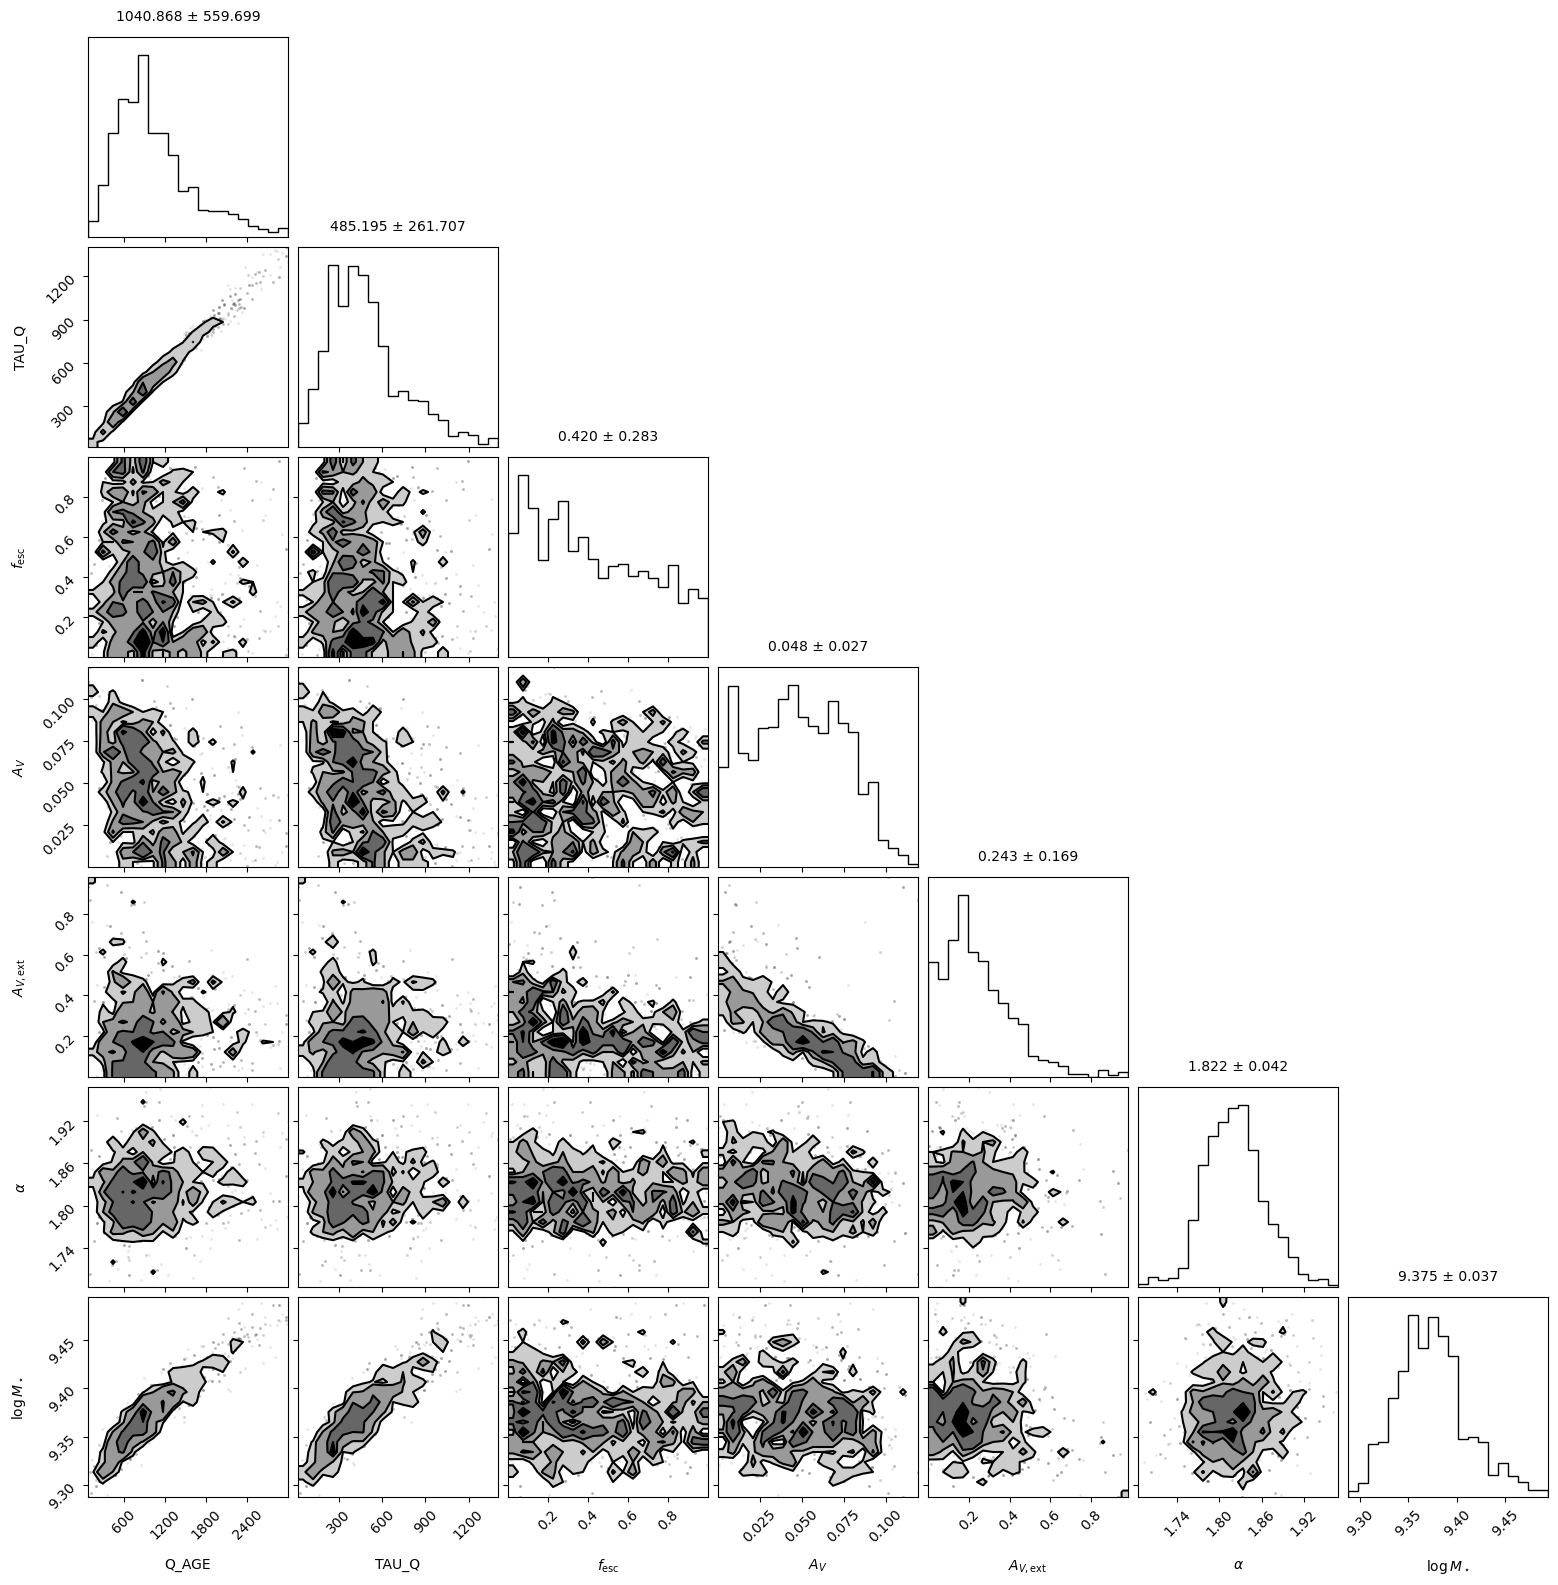

In [30]:
results_only_phot.cornerplot()

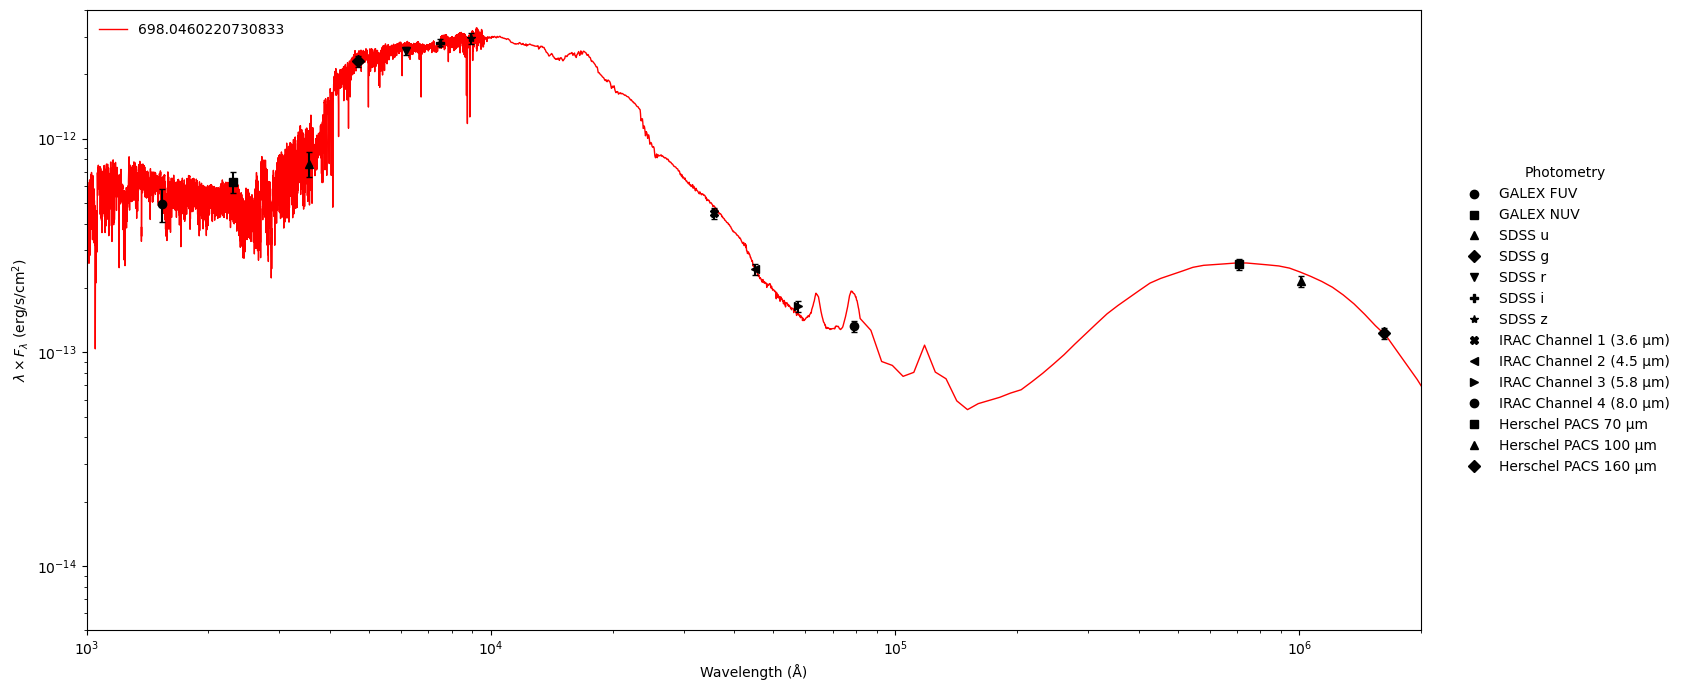

For model number:  1
GALEX FUV :  3.8610678231125997
GALEX NUV :  2.827335213159617
SDSS u :  3.011143996918394
SDSS g :  2.4902229945391516
SDSS r :  2.3522697588134913
SDSS i :  2.6332710305021854
SDSS z :  2.1068607922283427
IRAC Channel 1 (3.6 μm) :  1.5282720311899753
IRAC Channel 2 (4.5 μm) :  1.956820215599305
IRAC Channel 3 (5.8 μm) :  3.1018373702822357
IRAC Channel 4 (8.0 μm) :  2.566809047893866
Herschel PACS 70 μm :  0.12328421378227794
Herschel PACS 100 μm :  -1.619088272928472
Herschel PACS 160 μm :  0.0007162941713882015
TOTAL_PHOT:  26.940822509264354




In [33]:
results_only_phot.fit_diagnostic(
        method='ML',
        #models=[first_model,second_model,third_model],
        show_all_spectral_lines=True,show_H_lines=False,show_atmospheric_lines=True,        
        #winf = 4900,wsup=5100,
        spec_legend_pars='Q_AGE',#spec_legend_pars,
        color=['red','cyan','green'],
        figsize=(20,8),
        winf_phot=1e3,wsup_phot=2e6,
        ymin=0.5e-14,ymax=4e-12,)


In [41]:
results_with_spec = fitter.run_fit(phot=phot, 
                         bands=bands, 
                         spec=mock_spec,
                         spectral_range=[4500,7000],
                         fix_pars={'BURST':0,'METAL':0.017,
                                   'ion_gas':-3.94,'age_gas':13,
                                  'redshift':redshift,'luminosity_distance':luminosity_distance}, 
                        custom_priors=custom_prior,
                        nlive=100,
                        dlogz=0.1,
                        )

Using the following photometric filters: galex_fuv, galex_nuv, sdss_u, sdss_g, sdss_r, sdss_i, sdss_z, spitzer_irac_1, spitzer_irac_2, spitzer_irac_3, spitzer_irac_4, herschel_pacs_70um, herschel_pacs_100um, herschel_pacs_160um

Priors:
  - Q_AGE: Uniform(2, 3000)
  - TAU_Q: Uniform(1, 2000)
  - fesc: Uniform(0.0, 1.0)
  - av: Uniform(0.0, 0.2)
  - av_ext: Uniform(0.0, 1.0)
  - alpha: Uniform(0.0625, 4.0)
  - m_star: Uniform(8.2, 9.5)
  - vel_sys: Uniform(-500, 500)
  - sigma_vel: Uniform(0, 400)
  - spec_noise_scale: Gaussian(mean=0, sigma=4)
Initializing live points


3497it [37:25,  1.56it/s, +100 | bound: 212 | nc: 1 | ncall: 97915 | eff(%):  3.677 | loglstar:   -inf < 90035.117 <    inf | logz: 90002.622 +/-  0.535 | dlogz:  0.001 >  0.100]


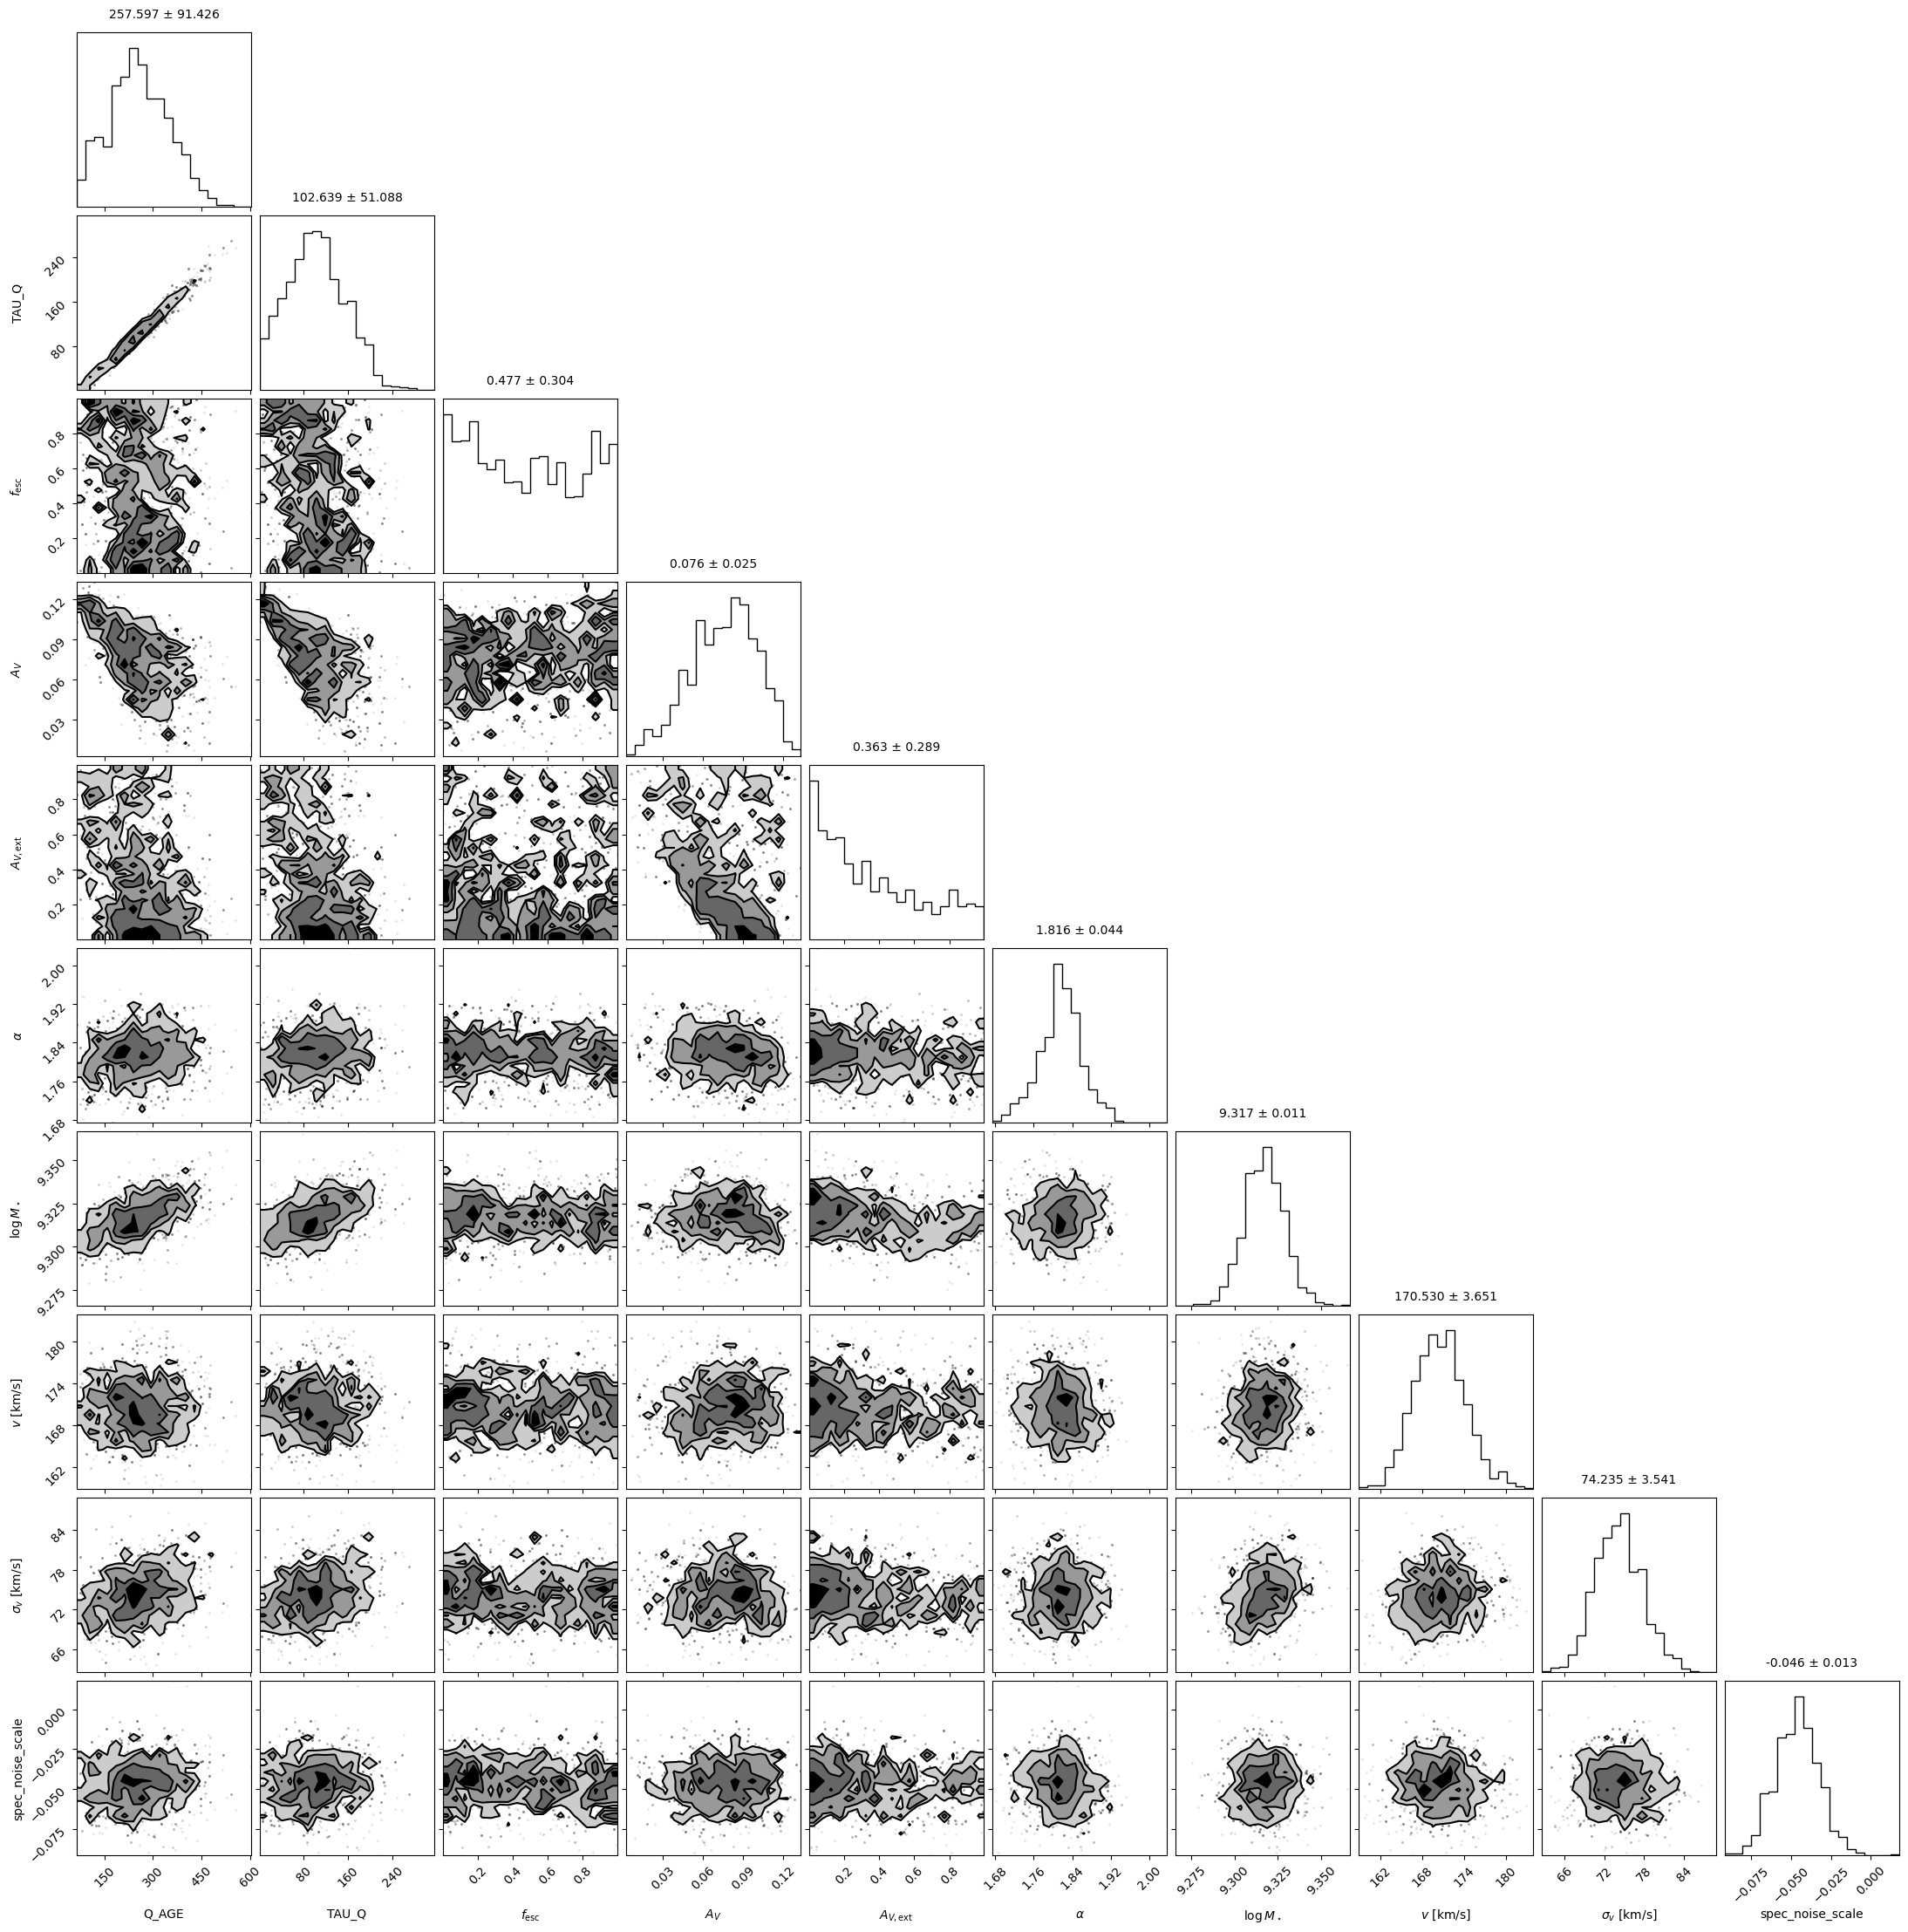

In [42]:
results_with_spec.cornerplot()

In [46]:
hdr = results_only_phot.best_model().header
vel_sys   = results_with_spec.best_model().header["vel_sys"]
sigma_vel = results_with_spec.best_model().header["sigma_v"]
av        = hdr["av"]
av_ext    = hdr["av_ext"]
alpha     = hdr["alpha"]
fesc      = hdr["fesc"]
ion_gas   = hdr["ion_gas"]
age_gas   = hdr["age_gas"]
Q_AGE     = hdr["Q_AGE"]
TAU_Q     = hdr["TAU_Q"]
BURST     = hdr["BURST"]
METAL     = hdr["METAL"]
m_star    = hdr["mstar"]
redshift  = hdr["redshift"]
luminosity_distance = hdr["dl_mpc"]

results_only_phot_ = fitter.synthetic_spectrum(
    vel_sys=vel_sys,
    sigma_vel=sigma_vel,
    av=av,av_ext=av_ext,alpha=alpha,
    fesc=fesc,ion_gas=ion_gas,age_gas=age_gas,
    Q_AGE=Q_AGE,
    TAU_Q=TAU_Q,
    BURST=BURST,METAL=METAL,
    m_star=m_star,
    redshift=redshift,luminosity_distance=luminosity_distance)


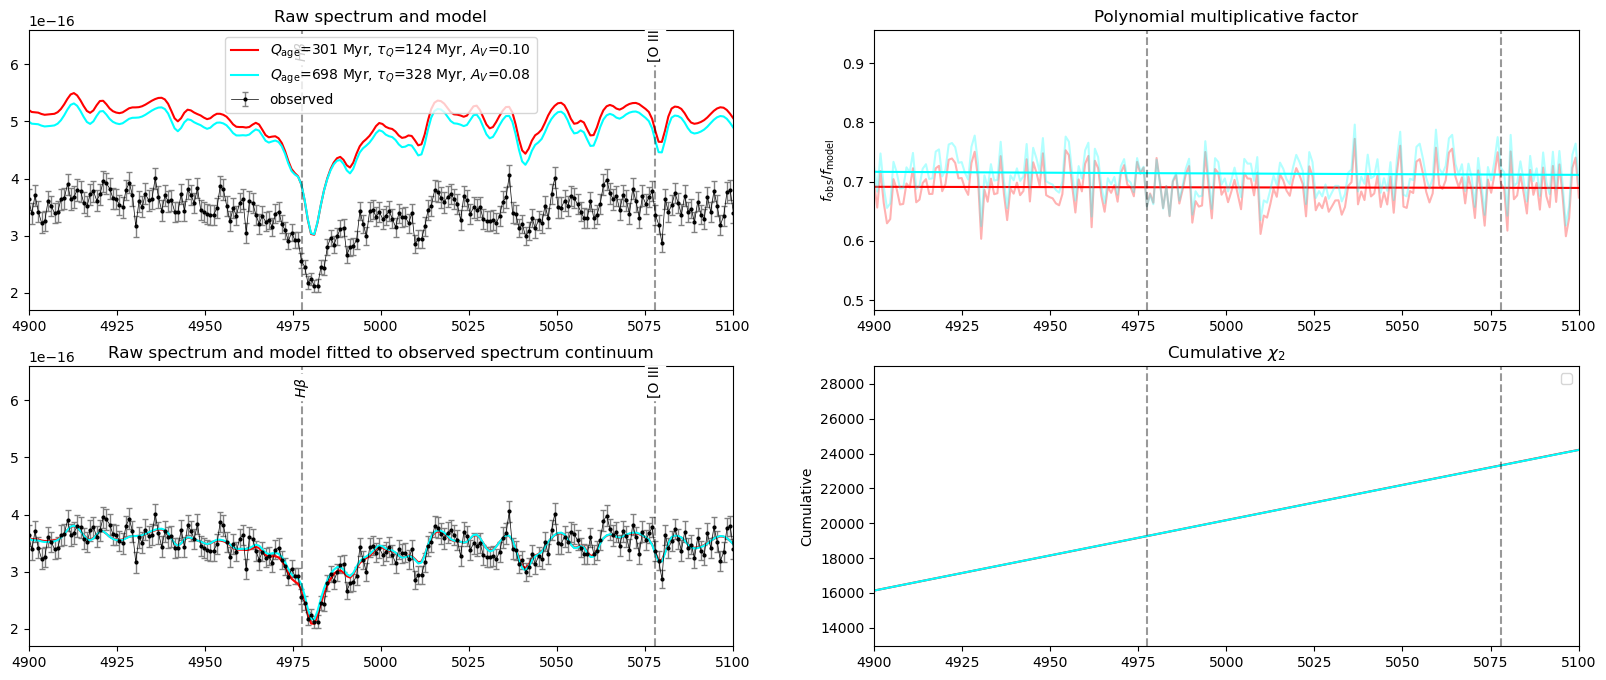

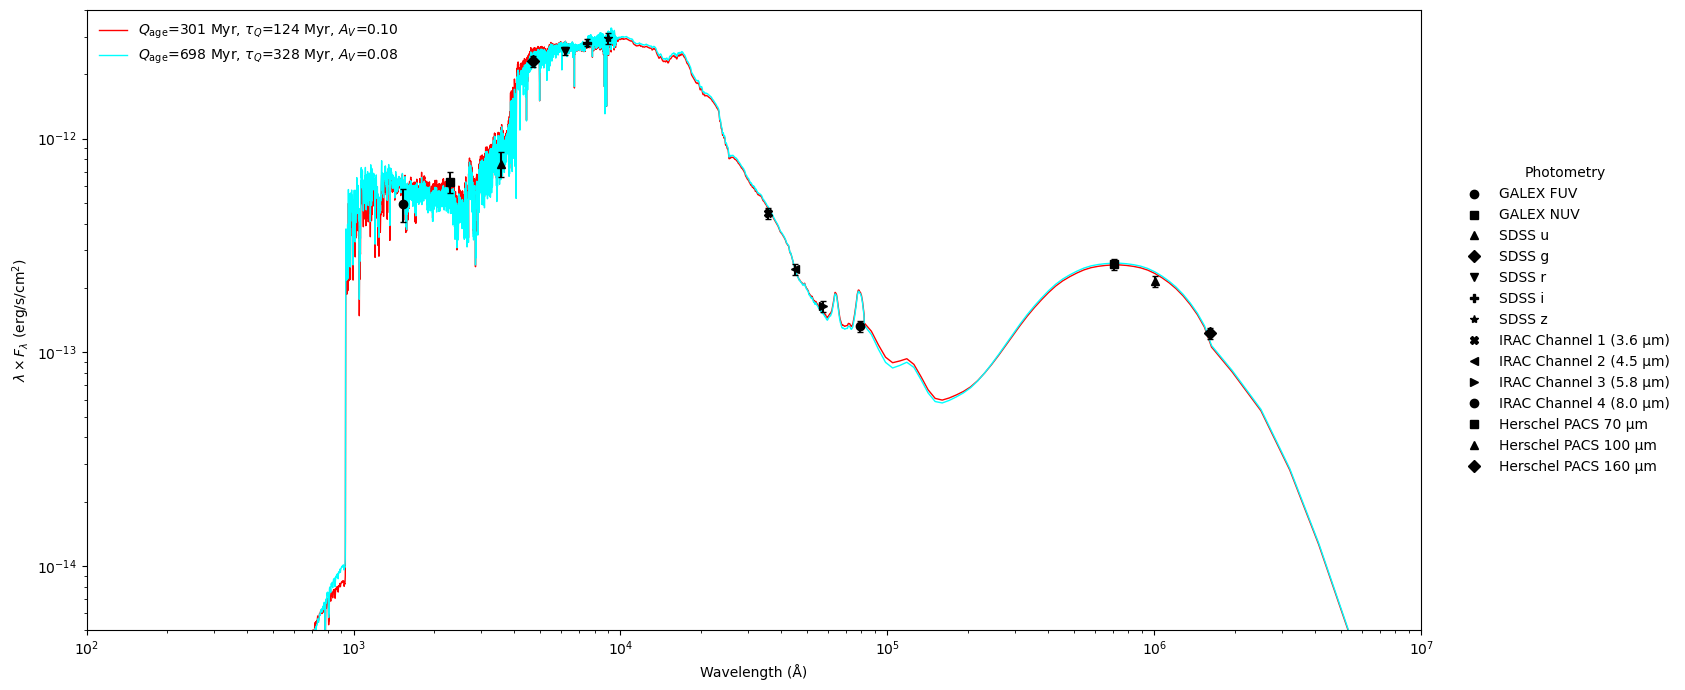

For model number:  1
GALEX FUV :  3.9057612529040426
GALEX NUV :  3.592396857538687
SDSS u :  2.349333469531147
SDSS g :  2.92480436072445
SDSS r :  2.1936786083771285
SDSS i :  2.5675735957103227
SDSS z :  2.066220120973479
IRAC Channel 1 (3.6 μm) :  1.8258544202072993
IRAC Channel 2 (4.5 μm) :  1.9481433102004675
IRAC Channel 3 (5.8 μm) :  3.0722831155504595
IRAC Channel 4 (8.0 μm) :  2.057385701855326
Herschel PACS 70 μm :  0.13643315060711084
Herschel PACS 100 μm :  -1.134155723347078
Herschel PACS 160 μm :  0.0647363508707794
TOTAL_PHOT:  27.57044859170362
TOTAL_SPEC:  90001.92610804352
TOTAL_PHOT+SPEC:  90029.49655663523


For model number:  2
GALEX FUV :  3.8544818106504404
GALEX NUV :  2.834107080950182
SDSS u :  3.0185912587400408
SDSS g :  2.4866221023925412
SDSS r :  2.340229666231801
SDSS i :  2.6342963206220014
SDSS z :  2.106246876811407
IRAC Channel 1 (3.6 μm) :  1.4854580365030259
IRAC Channel 2 (4.5 μm) :  1.9017392330217553
IRAC Channel 3 (5.8 μm) :  3.102759871487117

In [48]:
spec_legend_pars = {
    'Q_AGE': dict(label="$Q_\\text{age}$", unit="Myr", fmt=".0f"),
    'TAU_Q': dict(label="$\\tau_Q$", unit="Myr", fmt=".0f"),
    'av':    dict(label="$A_V$", unit="", fmt=".2f"),
}

results_with_spec.fit_diagnostic(
        method='ML',
        models=[results_with_spec.best_model(),results_only_phot_],
        show_all_spectral_lines=True,show_H_lines=False,show_atmospheric_lines=True,        
        winf = 4900,wsup=5100,
        spec_legend_pars=spec_legend_pars,
        color=['red','cyan','green'],
        figsize=(20,8),
        #winf_phot=1e3,wsup_phot=2e6,
        ymin=0.5e-14,ymax=4e-12,)

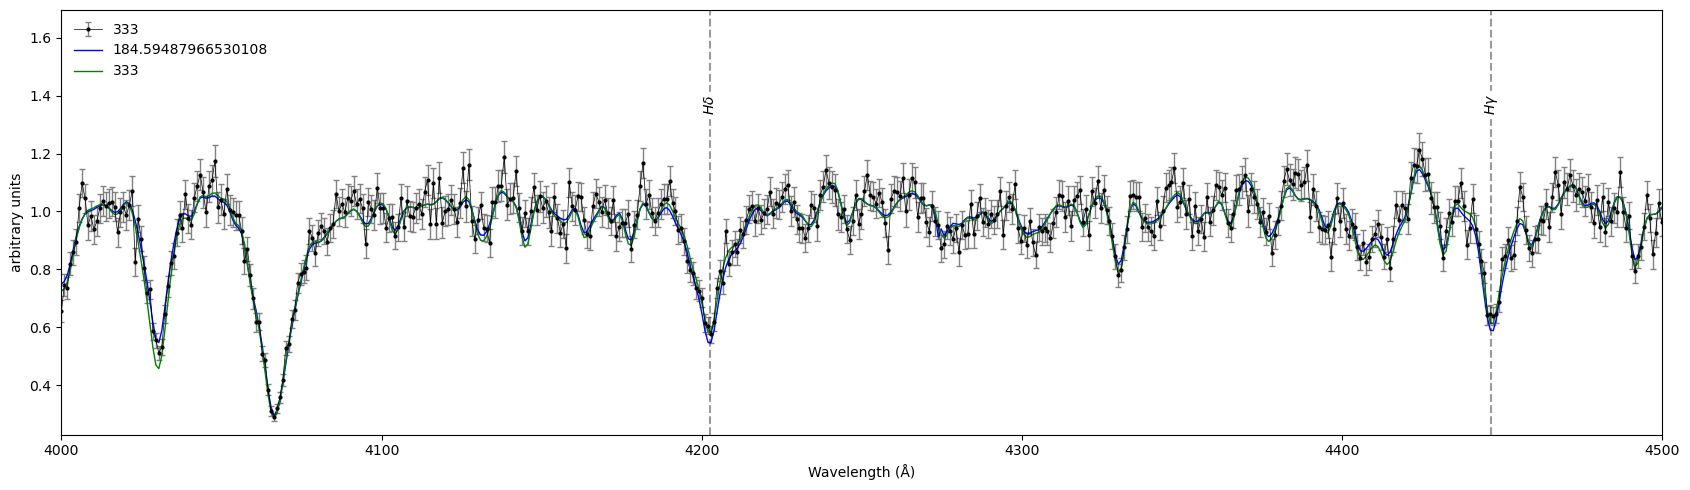

In [139]:

legend = 'Q_AGE'

other_synth_spec = fitter.synthetic_spectrum(
    vel_sys=vel_sys,
    sigma_vel=sigma_vel,
    av=av,av_ext=av_ext,alpha=alpha,
    fesc=fesc,ion_gas=ion_gas,age_gas=age_gas,
    Q_AGE=333,
    TAU_Q=TAU_Q,
    BURST=BURST,METAL=METAL,
    m_star=m_star,
    redshift=redshift,luminosity_distance=luminosity_distance)


results.best_model().plot(figsize=(20,5), 
            remove_continuum=True,
            #draw_continuum=True,                      
             spectra=[mock_spec,results_with_spec.best_model(),other_synth_spec],
             #spectra=[spectra[0],results_with_spec.best_model(),spec_new],
            #normalized=True,
            #per_wavelength=True, 
            #phot_points=phot_list, phot_region='1', 
            
            show_all_spectral_lines=False,show_H_lines=True,show_atmospheric_lines=True,
            #zoom_on_line=['Ha','Hb'],
            #x_units='A',y_units='erg/s/cm2/A',
            #x_units='cm',y_units='mJy',
            #winf=1000,wsup=2e6,
            winf = 4000,wsup=4500,
            #ymin = 0.5,ymax=1.5,
            spec_legend_pars=legend,
            show_phot_legend=False,
            #show_spec_legend=True,
            ecolor='gray',
            color=['black','blue','green'],
           )

 

In [9]:
fitter.cornerplot(results)

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:1                                                                                    │
│                                                                                                  │
│ ❱ 1 fitter.cornerplot(results)                                                                   │
│   2                                                                                              │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
AttributeError: 'PFitter' object has no attribute 'cornerplot'

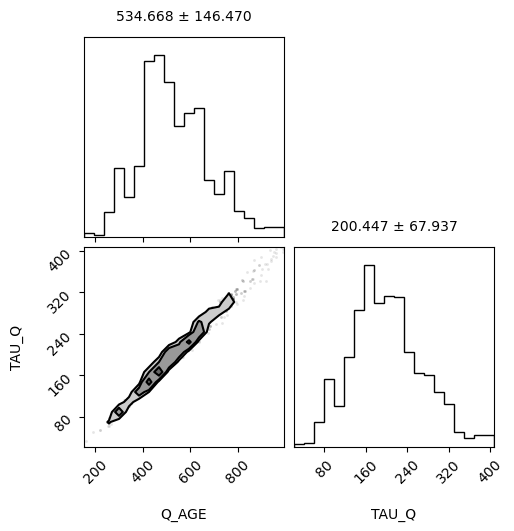

In [21]:
fitter.cornerplot(results)

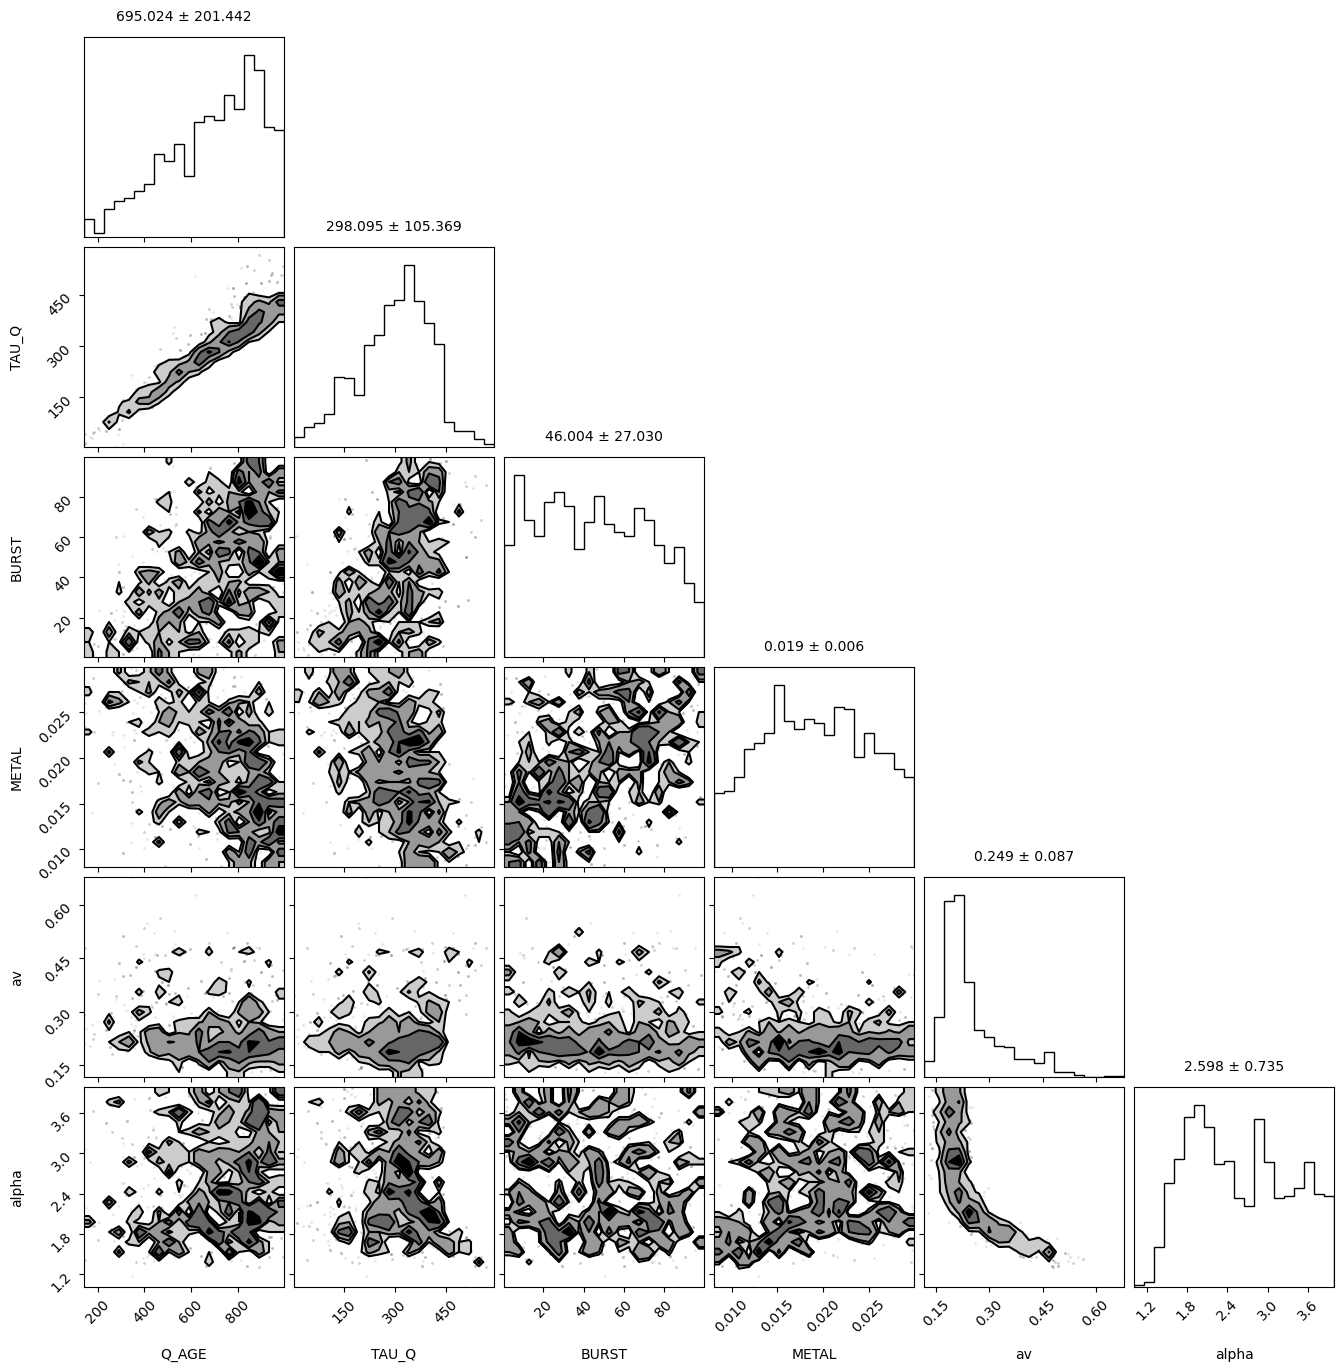

In [10]:
fitter.cornerplot(results)

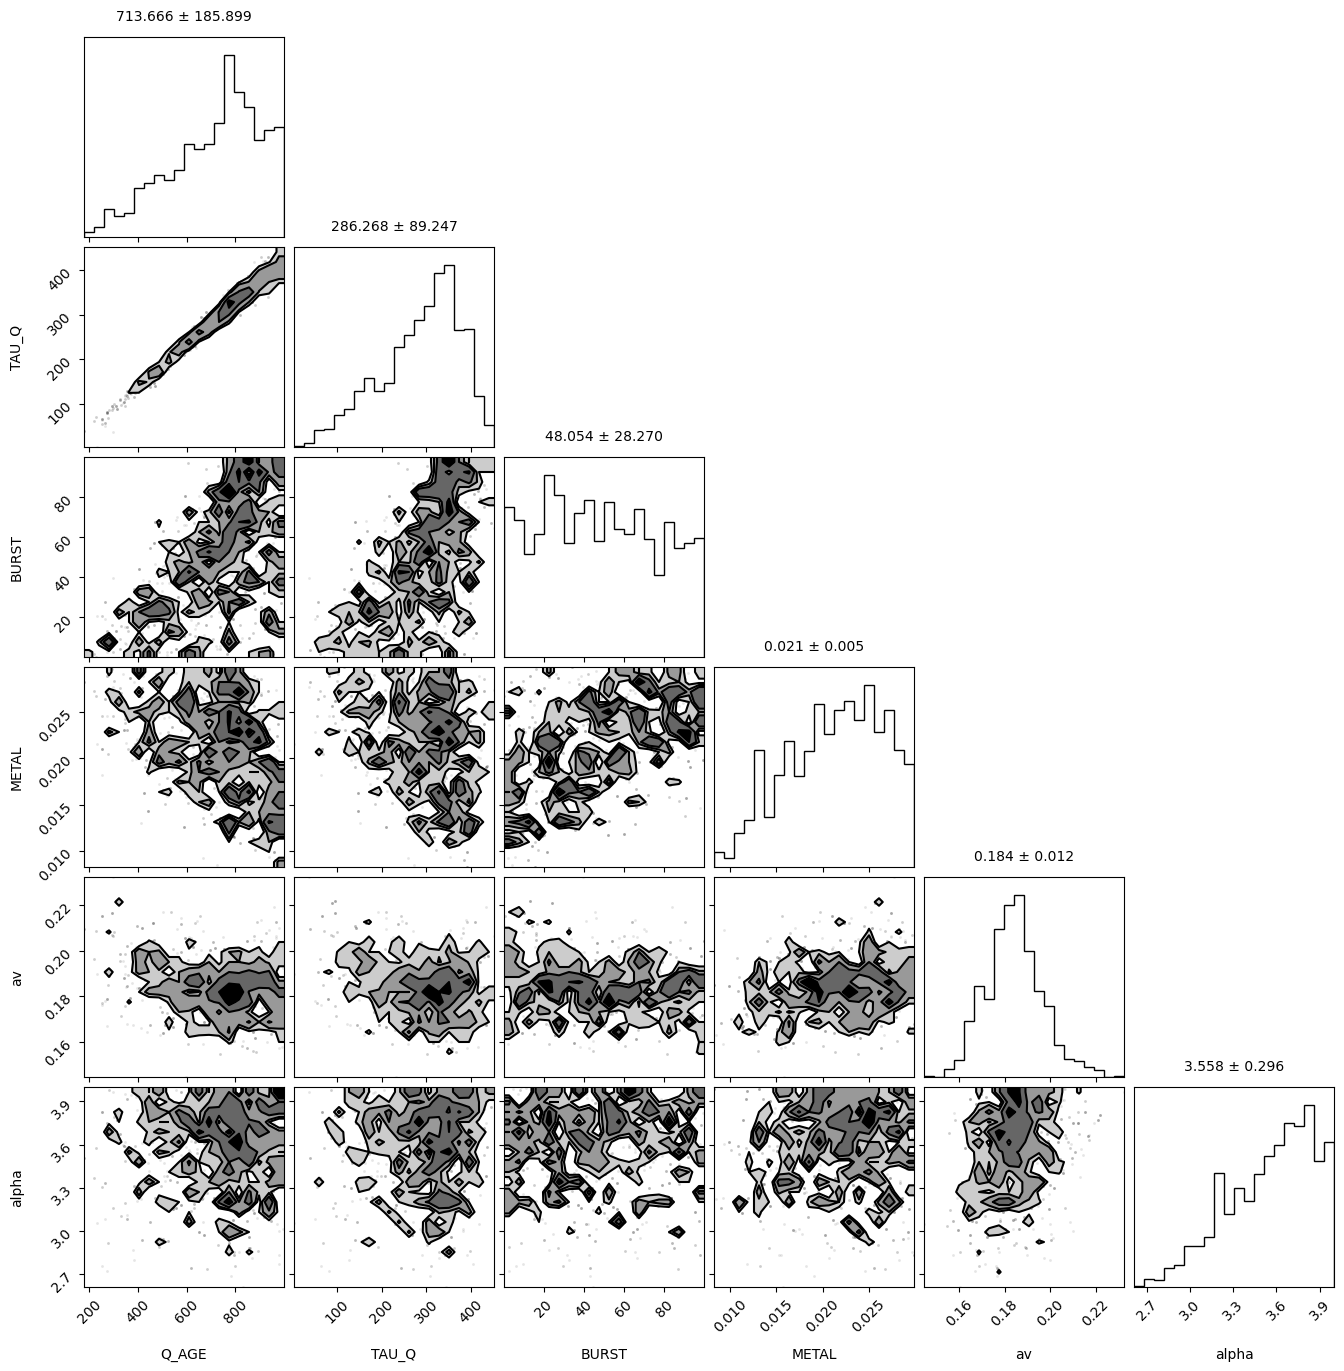

In [18]:
fitter.cornerplot(results_with_herschel)

In [30]:
fit_spec_2 = fitter.synthetic_spectrum(
            multi_component=True,
            Q_AGE=800,
            TAU_Q=320,
            #BURST=0,
            #METAL=0.017,
            fesc=0.5,
            av=1.2,
            av_ext= 0.0,
            alpha=3.5,
            m_star=9.2,
            ion_gas=-3.94,
            age_gas=13,
            redshift=0.02,
            dl=104,  # Luminosity distance in Mpc (assumed)
        )

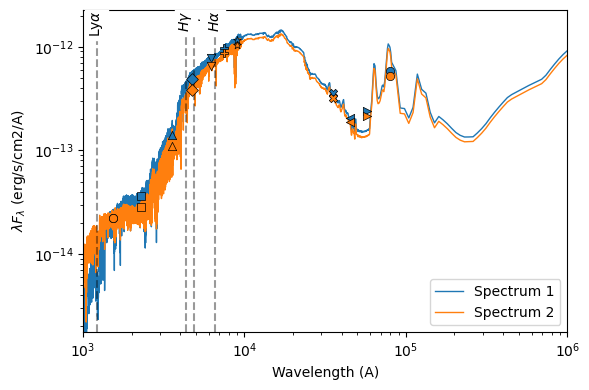

In [31]:
mock_spec.plot(spectra=[mock_spec,fit_spec_2],per_wavelength=True,phot_points=bands,phot_legend=True,
              winf=1000,wsup=1e6,show_H_lines=True)

In [78]:
import os, glob, re
import numpy as np
from astropy.io import fits
import tempfile

# Base directory containing the “DISKEVOL.RES_L0.05_V*” files
data_dir = "SFHs_Boissier/boissier_models_big_grid"

# Pattern to match files without “lignes” in their name
file_pattern = os.path.join(data_dir, "DISKEVOL.RES_L0.05_V*")

# Regex to extract the integer velocity after “_V”
vel_pattern = re.compile(r"_V(\d+)")
# First, collect (velocity, full_path) pairs
velocity_files = []
for full_path in glob.glob(file_pattern):
    fname = os.path.basename(full_path)
    if "lignes" in fname:
        continue
    m = vel_pattern.search(fname)
    if not m:
        continue
    velocity = int(m.group(1))
    velocity_files.append((velocity, full_path))

# Sort by velocity (ascending)
velocity_files.sort(key=lambda vf: vf[0])

# Now build the dictionary in sorted order
boissier_models = {}
for velocity, full_path in velocity_files:
    boissier_models[velocity] = {}   # Initialize nested dict for this velocity

    current_radius = None
    boissier_models_by_radius = {}   # Temporary storage: radius → list of rows

    with open(full_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("99999"):
                # Skip empty lines or separator lines
                continue

            if line.startswith("R ="):
                parts = line.split()
                try:
                    # Parse “R = 1.24 kpc” → radius = 1.24
                    current_radius = float(parts[2])
                    boissier_models_by_radius[current_radius] = []
                except (IndexError, ValueError):
                    current_radius = None
                continue

            if current_radius is None:
                continue

            parts = line.split()
            if len(parts) < 6:
                continue

            try:
                # Convert columns 1–5 to float
                row = [float(x) for x in parts[1:6]]
                boissier_models_by_radius[current_radius].append(row)
            except ValueError:
                continue

    # Convert each list of rows into a NumPy array, then store under data[velocity]
    for radius, rows in boissier_models_by_radius.items():
        boissier_models[velocity][radius] = np.array(rows)

# Example: print out velocity → radius → array shape (velocities will be in ascending order)
#for v in data:
#    for r in sorted(data[v]):
#        arr = data[v][r]
#        print(f"Velocity = {v} km/s, Radius = {r:.2f} kpc → Shape = {arr.shape}")
